In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LinearRegression

from pathlib import Path
from warnings import simplefilter

simplefilter("ignore")  # ignore warnings to clean up output cells

In [14]:
# https://www.kaggle.com/datasets/aradhanahirapara/product-retail-price-survey-2017-2025
df = pd.read_csv("data/Retail_Prices_of _Products.csv")
df.head()

,Year,Month,GEO,Product Category,Products,VALUE,Taxable,Total tax rate,Value after tax,Essential,COORDINATE,UOM
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,12.66,Essential,11.10,Dollars
1,2017,January,Province 1,Meat & Poultry,"Beef striploin cuts, per kilogram",21.94,No,11.0,21.94,Essential,11.20,Dollars
2,2017,January,Province 1,Meat & Poultry,"Beef top sirloin cuts, per kilogram",13.44,No,11.0,13.44,Essential,11.30,Dollars
3,2017,January,Province 1,Meat & Poultry,"Beef rib cuts, per kilogram",20.17,No,11.0,20.17,Essential,11.41,Dollars
4,2017,January,Province 1,Meat & Poultry,"Ground beef, per kilogram",9.12,No,11.0,9.12,Essential,11.40,Dollars


In [15]:
df['Date'] = df['Month'].astype(str) + ' ' + df['Year'].astype(str)
df['Date'] = pd.to_datetime(df['Date'], format='%B %Y')
df.head()

,Year,Month,GEO,Product Category,Products,VALUE,Taxable,Total tax rate,Value after tax,Essential,COORDINATE,UOM,Date
0,2017,January,Province 1,Meat & Poultry,"Beef stewing cuts, per kilogram",12.66,No,11.0,12.66,Essential,11.10,Dollars,2017-01-01
1,2017,January,Province 1,Meat & Poultry,"Beef striploin cuts, per kilogram",21.94,No,11.0,21.94,Essential,11.20,Dollars,2017-01-01
2,2017,January,Province 1,Meat & Poultry,"Beef top sirloin cuts, per kilogram",13.44,No,11.0,13.44,Essential,11.30,Dollars,2017-01-01
3,2017,January,Province 1,Meat & Poultry,"Beef rib cuts, per kilogram",20.17,No,11.0,20.17,Essential,11.41,Dollars,2017-01-01
4,2017,January,Province 1,Meat & Poultry,"Ground beef, per kilogram",9.12,No,11.0,9.12,Essential,11.40,Dollars,2017-01-01


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118482 entries, 0 to 118481
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Year              118482 non-null  int64         
 1   Month             118482 non-null  str           
 2   GEO               118482 non-null  str           
 3   Product Category  118482 non-null  str           
 4   Products          118482 non-null  str           
 5   VALUE             118482 non-null  float64       
 6   Taxable           118482 non-null  str           
 7   Total tax rate    118482 non-null  float64       
 8   Value after tax   118482 non-null  float64       
 9   Essential         118482 non-null  str           
 10  COORDINATE        118482 non-null  float64       
 11  UOM               118482 non-null  str           
 12  Date              118482 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(4), int64(1), str(7)
memory usage: 11.8 

In [17]:
df.isnull().sum()

Year                0
Month               0
GEO                 0
Product Category    0
Products            0
VALUE               0
Taxable             0
Total tax rate      0
Value after tax     0
Essential           0
COORDINATE          0
UOM                 0
Date                0
dtype: int64

In [18]:
df = df.drop(columns=['UOM', 'Value after tax'])
print(df.head())

   Year    Month         GEO Product Category  \
0  2017  January  Province 1   Meat & Poultry   
1  2017  January  Province 1   Meat & Poultry   
2  2017  January  Province 1   Meat & Poultry   
3  2017  January  Province 1   Meat & Poultry   
4  2017  January  Province 1   Meat & Poultry   

                              Products  VALUE Taxable  Total tax rate  \
0      Beef stewing cuts, per kilogram  12.66      No            11.0   
1    Beef striploin cuts, per kilogram  21.94      No            11.0   
2  Beef top sirloin cuts, per kilogram  13.44      No            11.0   
3          Beef rib cuts, per kilogram  20.17      No            11.0   
4            Ground beef, per kilogram   9.12      No            11.0   

   Essential  COORDINATE       Date  
0  Essential       11.10 2017-01-01  
1  Essential       11.20 2017-01-01  
2  Essential       11.30 2017-01-01  
3  Essential       11.41 2017-01-01  
4  Essential       11.40 2017-01-01  


In [19]:
# shifts the 'VALUE' column by 1 to create a lagged feature for 'VALUE'
df['Lag_VALUE'] = df['VALUE'].shift(1)

In [20]:
df = df.dropna()
print(df[['Date', 'VALUE', 'Lag_VALUE', 'Year', 'Month']].head())

        Date  VALUE  Lag_VALUE  Year    Month
1 2017-01-01  21.94      12.66  2017  January
2 2017-01-01  13.44      21.94  2017  January
3 2017-01-01  20.17      13.44  2017  January
4 2017-01-01   9.12      20.17  2017  January
5 2017-01-01   7.34       9.12  2017  January


In [21]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Select the columns to scale
columns_to_scale = ['VALUE', 'Total tax rate', 'Lag_VALUE']

# Apply the scaler to the selected columns
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# Display the scaled data
print(df[columns_to_scale].head())


      VALUE  Total tax rate  Lag_VALUE
1  0.449429             0.6   0.256698
2  0.272897             0.6   0.449429
3  0.412669             0.6   0.272897
4  0.183178             0.6   0.412669
5  0.146210             0.6   0.183178


In [22]:
import numpy as np

# Function to create sequences of time steps for LSTM
def create_sequences(data, target_column, time_steps=10):
    sequences = []
    targets = []
    
    for i in range(len(data) - time_steps):
        seq = data[i:i + time_steps].values
        target = data[target_column].iloc[i + time_steps]
        sequences.append(seq)
        targets.append(target)
    
    return np.array(sequences), np.array(targets)

# Define the features to use for the sequences
features = ['VALUE', 'Total tax rate', 'Lag_VALUE']

# Create sequences for LSTM (using 10 time steps)
X, y = create_sequences(df[features], 'VALUE', time_steps=10)

# Display the shape of the resulting sequences
print("LSTM Input Shape (X):", X.shape)
print("LSTM Target Shape (y):", y.shape)


LSTM Input Shape (X): (118471, 10, 3)
LSTM Target Shape (y): (118471,)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Training Set Shape (X_train):", X_train.shape)
print("Test Set Shape (X_test):", X_test.shape)


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Define the LSTM model
model = Sequential()

# Add an LSTM layer with 50 units and input shape corresponding to the time steps and features
model.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))

# Add a Dense output layer with one unit for regression
model.add(Dense(1))

# Compile the model using Mean Squared Error as the loss function and Adam optimizer
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=2)

# Display the model summary
model.summary()


Training Set Shape (X_train): (94776, 10, 3)
Test Set Shape (X_test): (23695, 10, 3)


2026-09-05 18:26:46.502939: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-09-05 18:26:46.502990: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2026-09-05 18:26:46.502998: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2026-09-05 18:26:46.503040: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-05 18:26:46.503052: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/20


2026-09-05 18:26:47.015282: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


2962/2962 - 21s - 7ms/step - loss: 0.0071 - val_loss: 0.0108
Epoch 2/20
2962/2962 - 19s - 6ms/step - loss: 0.0044 - val_loss: 0.0072
Epoch 3/20
2962/2962 - 19s - 6ms/step - loss: 0.0029 - val_loss: 0.0050
Epoch 4/20
2962/2962 - 19s - 6ms/step - loss: 0.0021 - val_loss: 0.0037
Epoch 5/20
2962/2962 - 19s - 7ms/step - loss: 0.0016 - val_loss: 0.0028
Epoch 6/20
2962/2962 - 19s - 7ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 7/20
2962/2962 - 19s - 7ms/step - loss: 8.7035e-04 - val_loss: 0.0021
Epoch 8/20
2962/2962 - 19s - 6ms/step - loss: 7.4122e-04 - val_loss: 0.0020
Epoch 9/20
2962/2962 - 20s - 7ms/step - loss: 6.4394e-04 - val_loss: 0.0021
Epoch 10/20
2962/2962 - 20s - 7ms/step - loss: 5.8089e-04 - val_loss: 0.0016
Epoch 11/20
2962/2962 - 19s - 7ms/step - loss: 5.3690e-04 - val_loss: 0.0018
Epoch 12/20
2962/2962 - 21s - 7ms/step - loss: 5.0366e-04 - val_loss: 0.0015
Epoch 13/20
2962/2962 - 20s - 7ms/step - loss: 4.8248e-04 - val_loss: 0.0012
Epoch 14/20
2962/2962 - 20s - 7ms/step - lo

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,555 (127.17 KB)

 Trainable params: 10,851 (42.39 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 21,704 (84.79 KB)

741/741 - 2s - 2ms/step - loss: 0.0010
Test Loss: 0.0010440665064379573


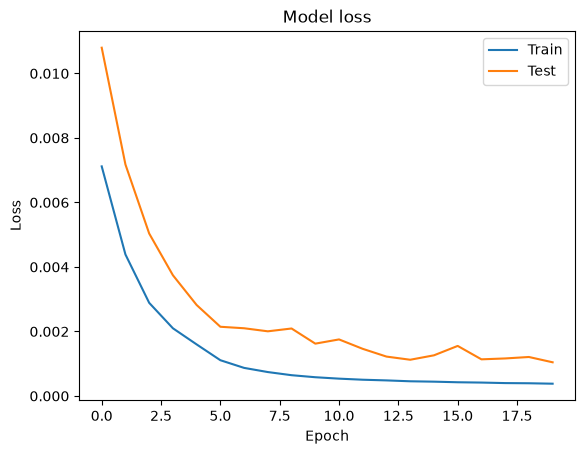

In [24]:
# Evaluate the model on the test set
test_loss = model.evaluate(X_test, y_test, verbose=2)
print("Test Loss:", test_loss)

# Plot learning curves
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper right')
plt.show()

In [25]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Reshape predictions and test values (if needed) for easier comparison
y_pred = y_pred.flatten()
y_test_flat = y_test.flatten()

# Display the first few predictions and actual values
for i in range(5):
    print(f"Predicted: {y_pred[i]}, Actual: {y_test_flat[i]}")


741/741 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predicted: 0.07721494138240814, Actual: 0.08369678089304257
Predicted: 0.11374811828136444, Actual: 0.11671858774662511
Predicted: 0.08867200464010239, Actual: 0.09117341640706127
Predicted: 0.05653439462184906, Actual: 0.07476635514018691
Predicted: -0.012645311653614044, Actual: 0.030114226375908618


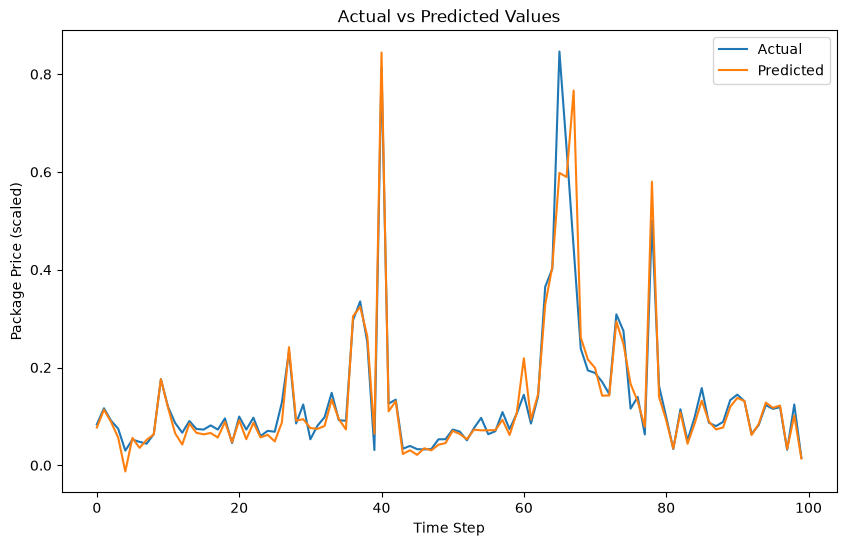

In [26]:
import matplotlib.pyplot as plt

# Plot the first 100 actual vs predicted values
plt.figure(figsize=(10,6))
plt.plot(y_test_flat[:100], label='Actual')
plt.plot(y_pred[:100], label='Predicted')
plt.title('Actual vs Predicted Values')
plt.xlabel('Time Step')
plt.ylabel('Package Price (scaled)')
plt.legend()
plt.show()


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate MAE
mae = mean_absolute_error(y_test_flat, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred))
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Calculate R² score
r2 = r2_score(y_test_flat, y_pred)
print(f"R² Score: {r2}")


Mean Absolute Error (MAE): 0.020044260120427905
Root Mean Squared Error (RMSE): 0.03231201667359499
R² Score: 0.9386113551731166
